Итоговый проект по модулю "Статистика и математика"

Статистический анализ факторов, влияющих на прибыльность розничных продаж

---

1. Постановка задачи

2. Описание данных

3. Подготовка данных

4. Разведочный анализ данных (EDA)

5. Проверка статистических гипотез

6. Итоговые выводы

7. Бизнес рекомендации

8. Ограничения исследования

1. Постановка задачи

Целью исследования является статистический анализ данных о розничных продажах с целью выявления факторов, оказывающих влияние на прибыльность продаж, эффективность различных типов магазинов, категорий товаров и используемых маркетинговых инструментов (скидок).

Исследование проводится на основе исторических данных о продажах, включающих сведения о товарах, магазинах, клиентах, сотрудниках и финансовых показателях. 

Полученные результаты могут быть использованы руководством компании для принятия решений в области управления ассортиментом, ценовой политики и повышения эффективности розничной сети.

2. Описание данных

2.1. Источник данных

Для проведения статистического анализа используется синтетический датасет розничных продаж, разработанный в рамках предыдущего проекта по Power BI. Данные моделируют деятельность сети розничных магазинов за период с 2023 по 2025 годы и включают информацию о продажах, товарах, магазинах, покупателях и сотрудниках.

Основным объектом исследования является таблица fact_sales, содержащая сведения о каждой операции продажи.

2.2. Описание признаков датасета

Таблица fact_sales содержит информацию о каждой операции продажи и включает 16 признаков, характеризующих товар, магазин, покупателя, финансовые показатели и результат продажи.

| Поле                | Тип данных     | Описание                                                                       |
| ------------------- | -------------- | ------------------------------------------------------------------------------ |
| **sale_id**         | int64          | Уникальный идентификатор продажи                                               |
| **sale_date**       | datetime64[ns] | Дата совершения продажи                                                        |
| **store_id**        | int64          | Идентификатор магазина                                                         |
| **employee_id**     | int64          | Идентификатор сотрудника, оформившего продажу                                  |
| **product_id**      | int64          | Идентификатор товара                                                           |
| **customer_id**     | int64          | Идентификатор покупателя                                                       |
| **quantity**        | int64          | Количество проданных единиц товара (при возврате имеет отрицательное значение) |
| **unit_price**      | float64        | Цена одной единицы товара                                                      |
| **unit_cost**       | float64        | Себестоимость одной единицы товара                                             |
| **discount_pct**    | float64        | Размер скидки в долях единицы                                                  |
| **discount_amount** | float64        | Абсолютная сумма предоставленной скидки                                        |
| **revenue**         | float64        | Выручка по продаже с учётом скидки                                             |
| **cost**            | float64        | Себестоимость реализованного товара                                            |
| **profit**          | float64        | Прибыль по продаже (`revenue - cost`)                                          |
| **payment_method**  | object         | Способ оплаты покупки (Card, Cash, Online)                                     |
| **is_return**       | bool           | Признак возврата товара (`True` — возврат, `False` — обычная продажа)          |


Таблица содержит как количественные, так и категориальные признаки, что позволяет применять широкий спектр методов статистического анализа. Количественные показатели будут использоваться для расчёта описательных статистик, анализа распределений и проверки гипотез о средних значениях, а категориальные признаки — для исследования различий между группами и проверки гипотез о независимости признаков.

2.3. Исследуемые показателия

В рамках настоящего исследования основное внимание уделяется следующим показателям:

- profit — основной показатель эффективности продажи;
- revenue — выручка от продажи;
- discount_pct — размер предоставленной скидки;
- quantity — количество реализованных единиц товара.

В качестве факторов, потенциально влияющих на данные показатели, рассматриваются:

- тип магазина;
- категория товара;
- регион магазина;
- ценовой сегмент товара;
- способ оплаты;
- наличие возврата.

In [101]:
#Импорт необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
%matplotlib inline

In [3]:
#считываем текущую директорию и родительскую директорию
current_dir = Path.cwd()
parent_dir = current_dir.parent

In [4]:
#считываем данные из CSV файла fact_sales.csv, который находится в папке data/raw
fact_sales = pd.read_csv(parent_dir / 'data' / 'raw' / 'fact_sales.csv', parse_dates=['sale_date'])

2.4 Общая характеристика датасета

На первом этапе исследования проведена общая оценка структуры набора данных. Определены размер датасета, типы признаков и их распределение по типам данных. Это позволяет убедиться в корректности загрузки данных и выбрать подходящие методы статистического анализа.

In [5]:
print(f'Количество наблюдений: {fact_sales.shape[0]}')
print(f'Количество признаков: {fact_sales.shape[1]}')

Количество наблюдений: 200000
Количество признаков: 16


Датасет содержит 200 000 наблюдений и 16 признаков, что обеспечивает достаточный объем данных для проведения описательной статистики и проверки статистических гипотез

In [6]:
fact_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 16 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   sale_id          200000 non-null  int64         
 1   sale_date        200000 non-null  datetime64[ns]
 2   store_id         200000 non-null  int64         
 3   employee_id      200000 non-null  int64         
 4   product_id       200000 non-null  int64         
 5   customer_id      200000 non-null  int64         
 6   quantity         200000 non-null  int64         
 7   unit_price       200000 non-null  float64       
 8   unit_cost        200000 non-null  float64       
 9   discount_pct     200000 non-null  float64       
 10  discount_amount  200000 non-null  float64       
 11  revenue          200000 non-null  float64       
 12  cost             200000 non-null  float64       
 13  profit           200000 non-null  float64       
 14  payment_method   200

Все признаки имеют корректные типы данных. Дата продажи представлена типом datetime64, финансовые показатели — типом float64, идентификаторы — целыми числами (int64), способ оплаты — категориальным признаком (object), а поле is_return имеет логический тип (bool).

3. Подготовка данных

3.1. Проверка полноты данных

Перед проведением статистического анализа необходимо убедиться в полноте набора данных. Наличие пропущенных значений может привести к смещению оценок, снижению мощности статистических критериев и искажению результатов исследования.

In [7]:
missing = fact_sales.isna().sum()
missing

sale_id            0
sale_date          0
store_id           0
employee_id        0
product_id         0
customer_id        0
quantity           0
unit_price         0
unit_cost          0
discount_pct       0
discount_amount    0
revenue            0
cost               0
profit             0
payment_method     0
is_return          0
dtype: int64

Провекра показала что пропущенные значения отсутствуют во всех признаках датасета. СЛедовательно дополнительная обработка пропусков не требуется, и все наблюдения могут быть использованы в дальнейшем анализе.

3.2. Проверка дубликатов

Следующим этапом выполняется проверка набора данных на наличие полностью дублирующихся записей. Дубли могут привести к смещению статистических характеристик и ошибочным выводам.

In [8]:
duplicates = fact_sales.duplicated().sum()
duplicates

np.int64(0)

Полностью дублирующиеся записи отсутствуют. Следовательно каждая строка датасета соответствует отдельной позиции.

3.3. Проверка основных статистических характеристик

In [9]:
fact_sales.describe().T

,count,mean,min,25%,50%,75%,max,std
sale_id,200000.0,100000.5,1.0,50000.75,100000.5,150000.25,200000.0,57735.171256
sale_date,200000,2024-07-16 10:35:23.568000256,2023-01-01 00:00:00,2023-10-18 00:00:00,2024-07-18 00:00:00,2025-04-22 00:00:00,2025-12-31 00:00:00,NaN
store_id,200000.0,16.32773,1.0,8.0,17.0,24.0,30.0,8.787173
employee_id,200000.0,190.938195,1.0,103.0,195.0,286.0,376.0,107.821778
product_id,200000.0,177.30458,1.0,65.0,181.0,271.0,400.0,115.599202
customer_id,200000.0,15094.29132,1.0,7551.0,15042.0,22737.0,29999.0,8718.205662
quantity,200000.0,1.51416,-5.0,1.0,1.0,2.0,5.0,1.046129
unit_price,200000.0,48.652429,4.46,19.87,34.77,67.69,231.07,39.408246
unit_cost,200000.0,31.337351,3.52,14.09,23.64,43.11,147.24,24.05159
discount_pct,200000.0,0.116199,0.0,0.07,0.12,0.16,0.28,0.058446


Анализ основных статистических характеристик позволяет выявить возможные аномальные значения, оченить диапазон изменений показателей и предварительно изучить особенности распределения данных.

- quantity min = -5 - отрицательные значения количества товара обусловлены операциями возрата продукции и не являются ошибкой данных;

- profit min = - 301.42 - отрицательные значения прибыли так же связаны с возвратами товара и отражают реальные бизнес - процессы

- discount_amount, revenue, cost - отрицательные значения так же обусловлены операциями возврата товаров, при которых продажа сторнируется.

In [10]:
fact_sales.loc[fact_sales['quantity'] < 0, 'is_return'].value_counts()

is_return
True    5975
Name: count, dtype: int64

In [11]:
fact_sales.loc[fact_sales['revenue'] < 0, 'is_return'].value_counts()

is_return
True    5975
Name: count, dtype: int64

3.4. Проверка логической корректности данных.

In [12]:
np.allclose(fact_sales['profit'], fact_sales['revenue'] - fact_sales['cost'])

True

Проверка показала, что прибыль во всех наблюдениях корректно рассчитывается как разница между выручкой и себестоимостью. Логических противоречий в расчетных показателях не обнаружено.

In [13]:
fact_sales['discount_pct'].between(0, 1).all()

np.True_

Проверка показала, что показатель скидки находится в допустимом диапазоне от 0 до 100%

По результатам проверки качества данных установлено, что датасет не содержит пропущенных значений и полных дубликатов. Основные финансовые показатели согласованы между собой, а обнаруженные отрицательные значения обусловлены бизнес-логикой возврата товаров. Таким образом данные обладают достаточным качеством и могут быть использованы для дальнейшего статистического анализа.

4. Разведочный анализ EDA

In [14]:
def analyze_numeric(dataframe, column):
    """Функция выполняет описательный статистический анализ количественного признака"""
    data = dataframe[column]
    count = data.count()
    mean = data.mean()
    median = data.median()
    mode = data.mode().iloc[0]
    variance = data.var() # дисперсия
    std = data.std() # стандартное отклонение
    cv = (std/mean) * 100 # коэффициент вариации
    skew = data.skew() # ассиметрия
    kurt = data.kurt() # эксцесс
    se = std/np.sqrt(count) #стандартная ошибка среднего
    confidence = 0.95 #95% доверительная вероятность
    alpha = 1 - confidence #уровень значимости
    K = (1-alpha/2) #критическая вероятность
    z = stats.norm.ppf(K) #критическое значение Z
    lower = mean - z*se #нижняя граница интервала
    upper = mean + z*se #верхняя граница интервала

    print('=====================================')
    print(f'Анализ признака: {column}')
    print('=====================================')
    print(f'Количество наблюдений: {count}')
    print()
    print(f'Среднее               : {mean:.2f}')
    print(f'Медиана               : {median:.2f}')
    print(f'Мода                  : {mode:.2f}')
    print()
    print(f'Дисперсия             : {variance:.2f}')
    print(f'Стандартное отклонение: {std:.2f}')
    print()
    print(f'Коэффициент вариации  : {cv:.2f}%')
    print()
    print(f'Асимметрия            : {skew:.2f}')
    print(f'Эксцесс               : {kurt:.2f}')
    print()
    print(f'{confidence*100}% доверительный интервал:')
    print(f'[{lower:.2f}; {upper:.2f}]')

        # Визуализация распределения признака
    fig, axes = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=(12, 7),
        gridspec_kw={'height_ratios': [3, 1]}
    )

    # Гистограмма с оценкой плотности распределения
    sns.histplot(
        data=data,
        bins=80,
        kde=True,
        ax=axes[0]
    )

    axes[0].axvline(
        mean,
        linestyle='--',
        label=f'Среднее: {mean:.2f}'
    )

    axes[0].axvline(
        median,
        linestyle=':',
        label=f'Медиана: {median:.2f}'
    )

    axes[0].axvline(
    0,
    color='red',
    linestyle='-.',
    linewidth=2,
    label='Нулевая прибыль'
)

    axes[0].set_title(f'Распределение признака «{column}»')
    axes[0].set_xlabel(column)
    axes[0].set_ylabel('Количество наблюдений')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Диаграмма размаха
    sns.boxplot(
        x=data,
        ax=axes[1]
    )

    axes[1].set_title(f'Диаграмма размаха признака «{column}»')
    axes[1].set_xlabel(column)
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    return {'count': count, 'mean': mean, 'median': median, 'mode': mode, 'variance': variance, 'std': std,
    'cv': cv, 'skew': skew, 'kurtosis': kurt, 'confidence': confidence, 'ci_lower': lower, 'ci_upper': upper}

4.1. Анализ распределения прибыли (Profit)

Прибыль является одним из ключевых финансовых показателей деятельности компании, поскольку отражает экономический результат каждой продажи. Анализ распределения прибыли позволяет оценить типичную доходность операций, степень изменчивости показателя, наличие асимметрии и экстремальных значений. Полученные результаты будут использованы при выборе статистических методов для дальнейшей проверки гипотез.

Анализ признака: profit
Количество наблюдений: 200000

Среднее               : 17.68
Медиана               : 9.60
Мода                  : 0.00

Дисперсия             : 677.43
Стандартное отклонение: 26.03

Коэффициент вариации  : 147.22%

Асимметрия            : 3.05
Эксцесс               : 20.12

95.0% доверительный интервал:
[17.57; 17.79]


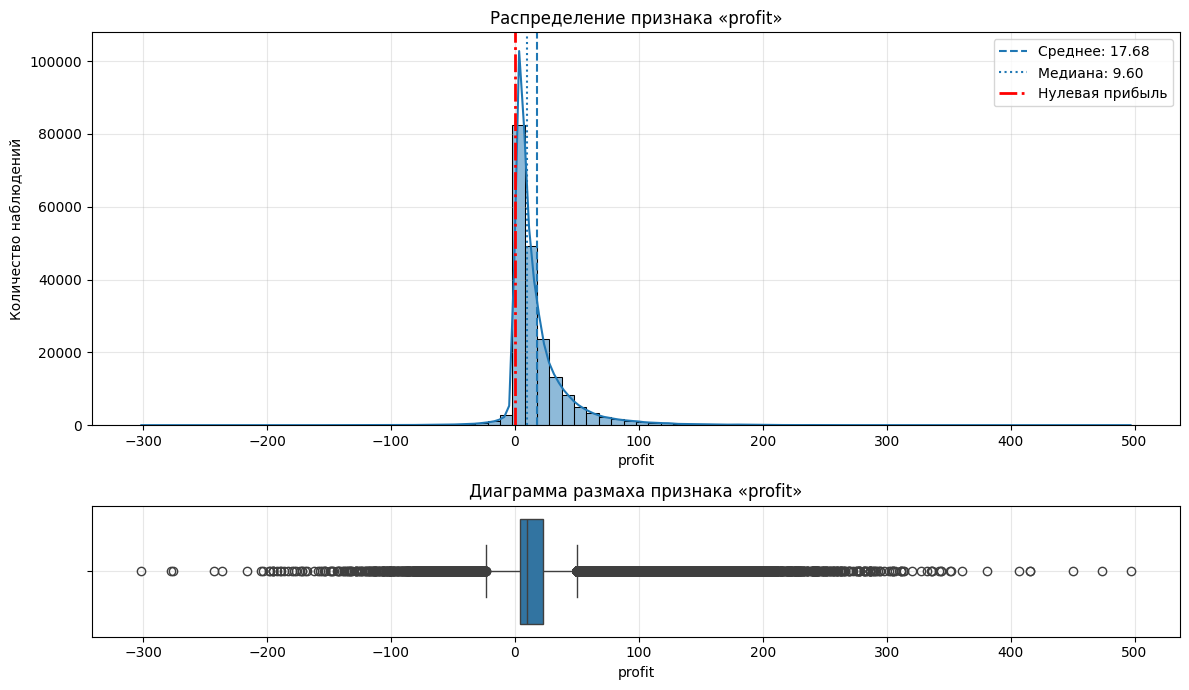

In [15]:
profit_stats = analyze_numeric(fact_sales, 'profit')

Выводы
1. Центральная тенденция

Средняя прибыль одной продажи составляет 17.68 денежных единиц, тогда как медианное значение равно 9.60. Существенное превышение среднего над медианой свидетельствует о наличии правосторонней асимметрии распределения. Это означает, что большинство продаж приносит относительно небольшую прибыль, тогда как небольшое число высокоприбыльных операций значительно увеличивает среднее значение.

2. Разброс данных

Коэффициент вариации составляет 147.22%, что значительно превышает рекомендуемое значение в 33%. Это свидетельствует о высокой неоднородности прибыли отдельных продаж и существенном разбросе наблюдений относительно среднего значения.

3. Форма распределения

Коэффициент асимметрии равен 3.05, что указывает на выраженную правостороннюю асимметрию распределения. Значение эксцесса 20.12 значительно превышает нулевое значение, характерное для нормального распределения, и свидетельствует о наличии тяжёлых хвостов и большого количества экстремальных наблюдений.

4. Визуальный анализ

Построенная гистограмма подтверждает результаты описательной статистики: большая часть наблюдений сосредоточена в области невысокой прибыли, при этом распределение имеет длинный правый хвост. Диаграмма размаха демонстрирует значительное количество выбросов как среди отрицательных, так и среди положительных значений. При этом отрицательные значения обусловлены операциями возврата товаров и отражают реальные бизнес-процессы, а не ошибки данных.

5. Доверительный интервал

95%-й доверительный интервал для среднего значения прибыли составил [17.57; 17.79]. Небольшая ширина интервала объясняется большим объёмом выборки (200 000 наблюдений) и свидетельствует о высокой точности оценки среднего значения прибыли.

Итоговый вывод

Анализ прибыли показал, что распределение существенно отличается от нормального: наблюдается выраженная правосторонняя асимметрия, высокая вариабельность и большое количество экстремальных значений. Это необходимо учитывать при дальнейшем исследовании, поскольку выбор статистических критериев должен основываться не только на размере выборки, но и на свойствах распределения данных.

Возможные направления дальнейшего исследования

Полученные результаты позволяют предположить, что уровень прибыли может существенно различаться в зависимости от характеристик продажи. На следующем этапе исследования будут проверены гипотезы о влиянии категории товара, региона, типа магазина, способа оплаты и других факторов на величину прибыли.



4.2. Анализ выручки (Revenue)

Выручка характеризует общий объем денежных поступлений от продажи товаров и является одним из основных финансовых показателей деятельности компании. Анализ распределения выручки позволяет оценить типичную стоимость продаж и выявить особенности формирования доходов.

Анализ признака: revenue
Количество наблюдений: 200000

Среднее               : 65.15
Медиана               : 43.34
Мода                  : 22.79

Дисперсия             : 6206.75
Стандартное отклонение: 78.78

Коэффициент вариации  : 120.93%

Асимметрия            : 2.31
Эксцесс               : 13.02

95.0% доверительный интервал:
[64.80; 65.49]


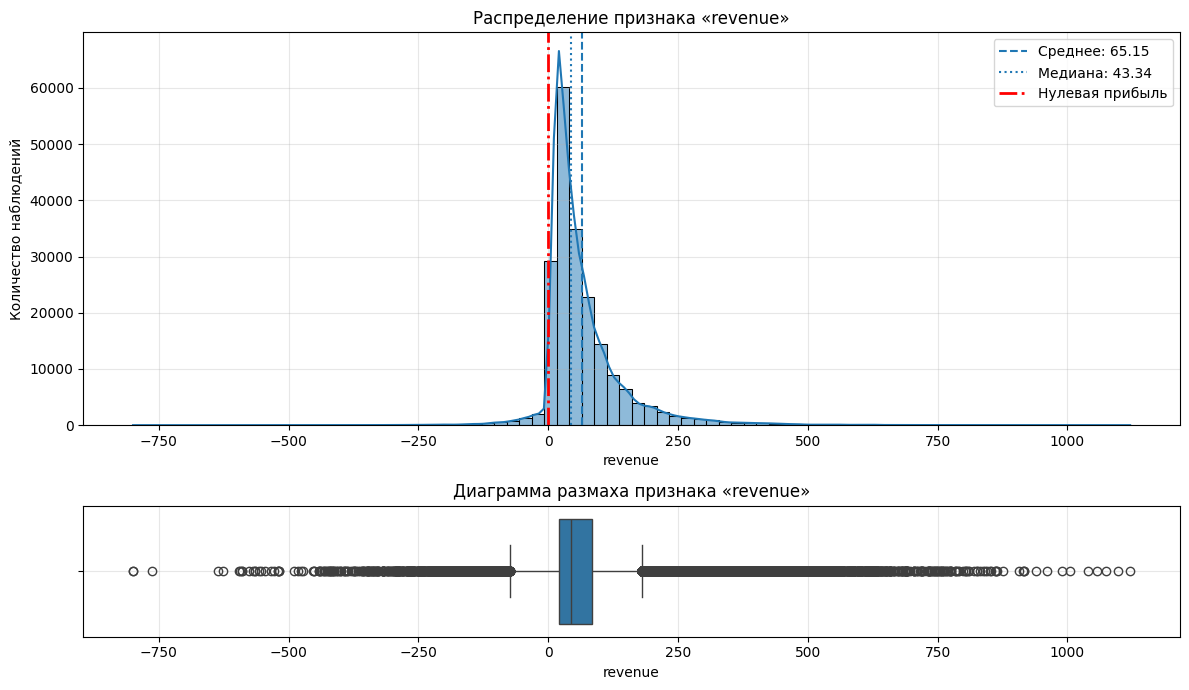

In [16]:
revenue_stats = analyze_numeric(fact_sales, 'revenue')

Вывод

Средняя выручка одной продажи составляет 65.15 денежных единиц, тогда как медианное значение равно 43.34. Превышение среднего значения над медианой свидетельствует о наличии выраженной правосторонней асимметрии распределения.

Коэффициент вариации составляет 120.93%, что указывает на высокую изменчивость выручки между отдельными продажами. Значения коэффициентов асимметрии (2.31) и эксцесса (13.02) существенно отличаются от характеристик нормального распределения и подтверждают наличие длинного правого хвоста и экстремальных наблюдений.

Построенные графики демонстрируют, что большинство продаж имеют относительно небольшую величину выручки, тогда как небольшое число дорогостоящих покупок формирует длинный правый хвост распределения. Отрицательные значения выручки обусловлены операциями возврата товаров и соответствуют особенностям бизнес-процессов компании.

4.3. Анализ количества товаров (Quantity)

Количество реализованных единиц товара характеризует объем каждой покупки и позволяет оценить типичное поведение покупателей. Анализ данного показателя помогает определить наиболее распространенный размер покупки, степень изменчивости спроса и наличие нетипичных операций.

Анализ признака: quantity
Количество наблюдений: 200000

Среднее               : 1.51
Медиана               : 1.00
Мода                  : 1.00

Дисперсия             : 1.09
Стандартное отклонение: 1.05

Коэффициент вариации  : 69.09%

Асимметрия            : 0.11
Эксцесс               : 3.73

95.0% доверительный интервал:
[1.51; 1.52]


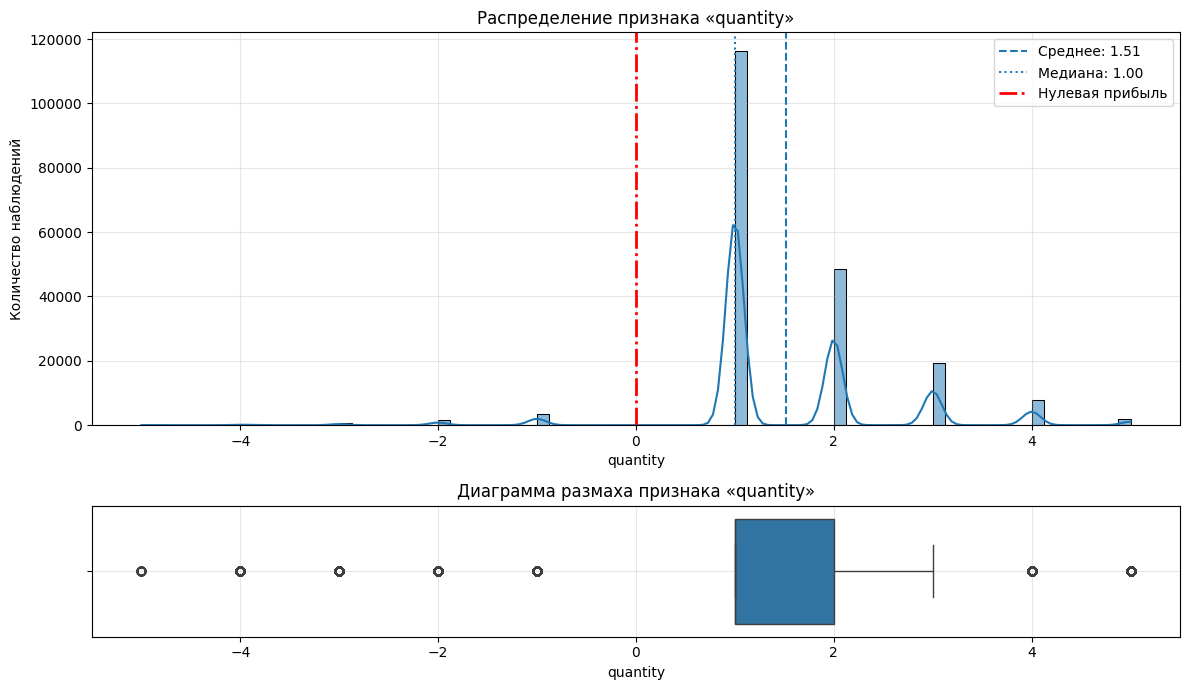

In [17]:
quantity_stats = analyze_numeric(fact_sales, 'quantity')

In [18]:
#частота распределения количества товаров в покупках
fact_sales['quantity'].value_counts(normalize=True).sort_index().mul(100).round(2)

quantity
-5     0.03
-4     0.11
-3     0.31
-2     0.73
-1     1.81
 1    58.15
 2    24.35
 3     9.68
 4     3.84
 5     0.98
Name: proportion, dtype: float64

Вывод

Среднее количество товаров в одной продаже составляет 1.51, при этом медиана и мода равны 1, что свидетельствует о преобладании покупок, состоящих из одной единицы товара.

Коэффициент вариации (69.09%) значительно ниже, чем у финансовых показателей, что говорит о меньшей изменчивости количества приобретаемых товаров. Значение коэффициента асимметрии (0.11) свидетельствует о практически симметричном распределении признака, тогда как повышенный эксцесс (3.73) объясняется его дискретной природой и концентрацией наблюдений около наиболее частых значений.

Анализ распределения показал, что 58.15% всех покупок содержат одну единицу товара, а 82.5% покупателей приобретают не более двух товаров за одну покупку. Покупки, включающие четыре и более товаров, встречаются менее чем в 5% случаев.

Отрицательные значения количества товара соответствуют операциям возврата. При этом большинство возвратов связано с возвратом одной единицы товара (1.81% всех операций), тогда как возвраты нескольких товаров одновременно встречаются значительно реже.

4.4. Анализ размера скидки (Amount_pct)

Размер предоставленной скидки является одним из инструментов ценовой политики компании и может оказывать влияние как на объем продаж, так и на прибыльность отдельных операций. Анализ распределения скидок позволяет оценить принятую маркетинговую стратегию и определить, насколько часто используются значительные скидки.

Анализ признака: discount_pct
Количество наблюдений: 200000

Среднее               : 0.12
Медиана               : 0.12
Мода                  : 0.13

Дисперсия             : 0.00
Стандартное отклонение: 0.06

Коэффициент вариации  : 50.30%

Асимметрия            : 0.07
Эксцесс               : -0.42

95.0% доверительный интервал:
[0.12; 0.12]


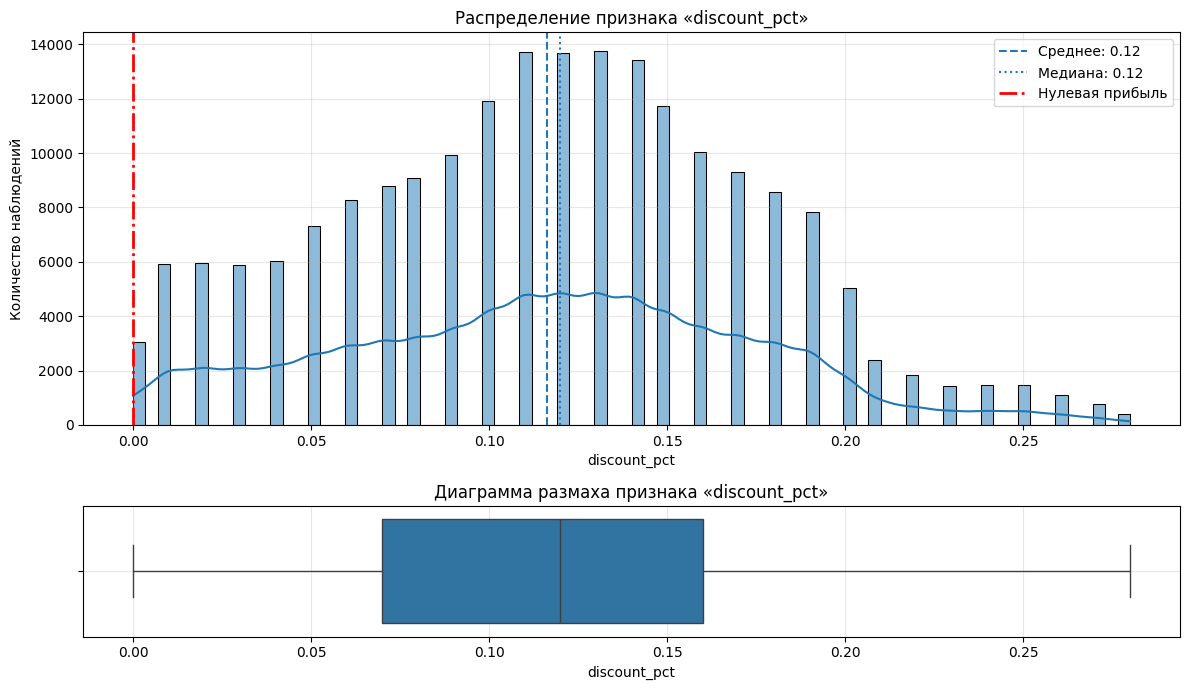

In [19]:
discount_stats = analyze_numeric(fact_sales, 'discount_pct')

Вывод

Средний размер предоставляемой скидки составляет 12%, при этом среднее, медиана и наиболее часто встречающееся значение практически совпадают. Это свидетельствует об отсутствии выраженного смещения распределения.

Коэффициент вариации составляет 50.3%, что значительно ниже аналогичного показателя для прибыли и выручки. Следовательно, политика предоставления скидок является существенно более стабильной, чем финансовые результаты отдельных продаж.

Коэффициент асимметрии (0.07) близок к нулю, а отрицательное значение эксцесса (−0.42) свидетельствует о достаточно равномерном распределении размеров скидок без выраженных экстремальных значений.

Построенные графики подтверждают результаты описательной статистики. Большинство продаж осуществляется со скидками, близкими к среднему уровню, тогда как очень большие или очень маленькие скидки используются сравнительно редко. Это позволяет сделать вывод о последовательной и контролируемой ценовой политике компании.

4.5 Общий вывод по разведочному анализу

В ходе разведочного анализа были исследованы основные количественные показатели набора данных: прибыль, выручка, количество товаров в покупке и размер предоставляемой скидки.

Анализ показал, что финансовые показатели (profit и revenue) характеризуются высокой вариабельностью, выраженной правосторонней асимметрией и наличием экстремальных значений. Это свидетельствует о существенной неоднородности продаж и наличии небольшого числа высокодоходных операций, оказывающих значительное влияние на средние значения.

В отличие от финансовых показателей, количество товаров в покупке (quantity) имеет практически симметричное распределение и отражает устойчивое покупательское поведение. Более 82% всех покупок содержат не более двух товаров, что свидетельствует о преобладании небольших покупок.

Размер предоставляемой скидки (discount_pct) оказался наиболее стабильным показателем исследования. Распределение скидок близко к симметричному, без выраженных выбросов, что свидетельствует о последовательной ценовой политике компании.

Полученные результаты позволяют перейти к следующему этапу исследования — проверке статистических гипотез, направленных на выявление факторов, оказывающих влияние на прибыльность продаж и другие ключевые показатели эффективности.

#Примечание

Перед следующим этапом - проверкой статистических гипотез, объединим таблицу с фактом продаж с таблицами справочниками, для получения большего количества деталей.

In [20]:
customers = pd.read_csv(parent_dir / 'data' / 'raw' / 'dim_customers.csv')
stores = pd.read_csv(parent_dir / 'data' / 'raw' / 'dim_stores.csv')
products = pd.read_csv((parent_dir / 'data' / 'raw' / 'dim_products.csv'))
full_sales = (fact_sales.merge(products, on = 'product_id')
              .merge(customers, on = 'customer_id')
              .merge(stores, on = 'store_id'))


5. Проверка статиститческих гипотез

5.1. Отличается ли средняя прибыль между категориями товаров?

Одной из ключевых задач розничной торговли является понимание прибыльности различных товарных категорий. Если отдельные категории товаров приносят существенно большую прибыль, компания может скорректировать ассортиментную политику, маркетинговые мероприятия и систему управления запасами. Для проверки данного предположения исследуем, отличается ли средняя прибыль между категориями товаров.

Формулировка гипотез
H₀

Средняя прибыль одинакова для всех категорий товаров.

μ1=μ2=μ3=…=μk

H₁

Средняя прибыль хотя бы одной категории отличается от остальных.

    Поскольку сравниваются средние значения количественного показателя (profit) сразу между несколькими независимыми категориями товаров, используется однофакторный дисперсионный анализ (One-Way ANOVA). 

In [21]:
#оценка данных
full_sales.groupby('category')['profit'].agg(['count', 'mean', 'median', 'std'])

,count,mean,median,std
category,,,,
Bathroom,41851,8.497019,6.26,9.261114
Cleaning,54018,4.734346,3.50,5.265519
Garden,18953,27.361157,20.19,29.322965
Kitchen,32692,40.049792,30.20,41.794930
Storage,31417,19.970706,14.81,20.949054
Textile,21069,22.268404,16.63,23.749761


In [22]:
full_sales['category'].value_counts()

category
Cleaning    54018
Bathroom    41851
Kitchen     32692
Storage     31417
Textile     21069
Garden      18953
Name: count, dtype: int64

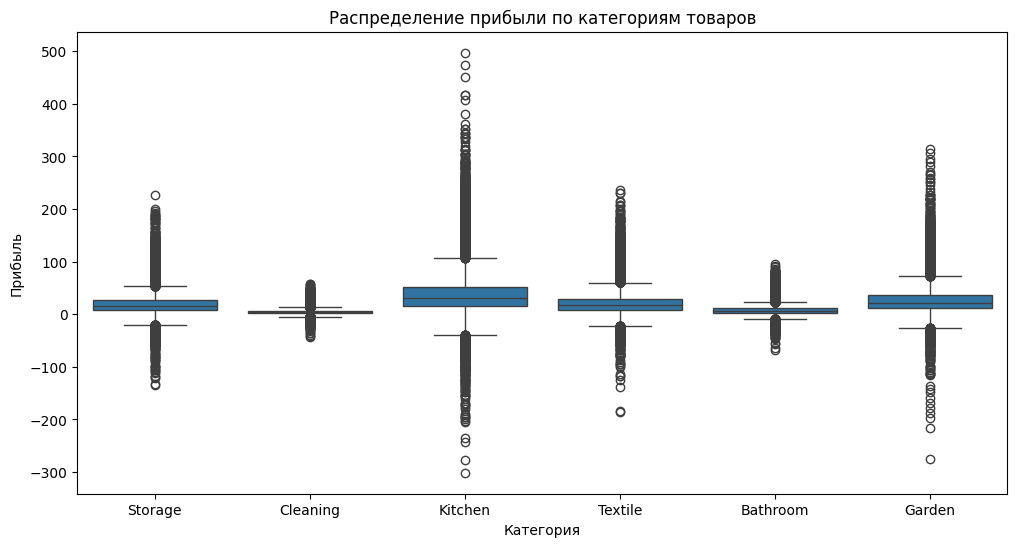

In [23]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=full_sales,
    x="category",
    y="profit"
)

plt.title("Распределение прибыли по категориям товаров")
plt.xlabel("Категория")
plt.ylabel("Прибыль")

plt.show()

In [24]:
#создаем группы данных по категориям
groups = [group['profit'].values for _, group in full_sales.groupby('category')]

Учитывая вариативность данных, перед проведением однофакторного дисперсионного анализа будет проверена гипотеза о равенстве дисперсий с помощью критерия Левена.

In [25]:
levene_stat, levene_p = stats.levene(*groups)
print(f"Statistic = {levene_stat:.3f}")
print(f"p-value = {levene_p:.5f}")

if levene_p > 0.05:
    print('Дисперсии можно считать равными')
else:
    print('дисперсии различаются')

Statistic = 8082.529
p-value = 0.00000
дисперсии различаются


In [26]:
#проводим тест ANOVA
f_stat, p_value = stats.f_oneway(*groups)
print(f'F-statistic = {f_stat:.3f}')
print(f'p_value = {p_value:.5f}')

F-statistic = 12029.821
p_value = 0.00000


In [27]:
alpha = 0.05
if p_value < alpha:
    print("\nОтвергаем H0.")
    print("Средняя прибыль статистически различается между категориями товаров.")
else:
    print("\nНет оснований отвергнуть H0.")
    print("Статистически значимых различий между категориями не обнаружено.")


Отвергаем H0.
Средняя прибыль статистически различается между категориями товаров.


Принмая во внимание что не соблюдается гомоскедастичность (равенство дисперсий), для получения подтверждения результаты ANOVA будут подтверждены непараметрическим критерием Краскела - Уоллиса

In [28]:
kruskal_st = stats.kruskal(*groups)[0]
kruskal_p = stats.kruskal(*groups)[1]

print(f"Statistic = {kruskal_st:.3f}")
print(f"p-value = {kruskal_p:.5f}")
if kruskal_p<alpha:
    print("\nОтвергаем H0.")
    print("Средняя прибыль статистически различается между категориями товаров.")
else:
    print("\nНет оснований отвергнуть H0.")
    print("Статистически значимых различий между категориями не обнаружено.")

Statistic = 83879.456
p-value = 0.00000

Отвергаем H0.
Средняя прибыль статистически различается между категориями товаров.


Вывод

Для сравнения средней прибыли между категориями товаров был выбран однофакторный дисперсионный анализ (ANOVA). Перед его применением были проверены предпосылки метода. Критерий Левена показал статистически значимые различия дисперсий между группами (p < 0.05), что свидетельствует о нарушении предпосылки гомоскедастичности.

Учитывая большой объём выборки, был выполнен классический дисперсионный анализ, а для подтверждения устойчивости полученного результата дополнительно применён непараметрический критерий Краскела–Уоллиса. Оба метода привели к одинаковому выводу о наличии статистически значимых различий между категориями товаров.

    Наибольшую среднюю прибыль приносит категория Kitchen, тогда как минимальная прибыль наблюдается в категории Cleaning. Разница между средними значениями составляет более восьми раз, что свидетельствует о существенных различиях в прибыльности различных товарных категорий.

5.2. Гипотеза № 2, отличается ли средняя прибыль покупки мужчин и женщин

Одной из задач маркетинговой аналитики является изучение покупательского поведения различных групп клиентов. Если средняя прибыль, получаемая от покупок мужчин и женщин, статистически различается, компания может учитывать эти особенности при разработке маркетинговых кампаний, программ лояльности и ассортиментной политики.

Формулируем гипотезы
H₀

Средняя прибыль покупки мужчин и женщин одинакова.

H₁

Средняя прибыль отличается.

In [29]:
#оценка данных

full_sales.groupby('gender')['profit'].agg(['count', 'mean', 'median', 'std'])

,count,mean,median,std
gender,,,,
Female,100369,17.684094,9.60,25.970209
Male,99631,17.674121,9.59,26.085080


In [30]:
#оценка размера выборок

full_sales['gender'].value_counts()

gender
Female    100369
Male       99631
Name: count, dtype: int64

In [31]:
#создаем выборки

male = full_sales.loc[full_sales['gender']=='Male', 'profit']

female = full_sales.loc[full_sales['gender']=='Female', 'profit']

In [34]:
#оценка равенства дисперсий
#H0 - Дисперсии равны
#H1 - дисперсии отличаются

levene_stat, levene_p = stats.levene(male, female)
print(f"Statistic = {levene_stat:.3f}")
print(f"p-value = {levene_p:.5f}")

if levene_p > 0.05:
    print('Дисперсии можно считать равными')
else:
    print('дисперсии различаются')

Statistic = 0.012
p-value = 0.91276
Дисперсии можно считать равными


In [35]:
#Проводим статистический t-тест
t_stat, p_value = stats.ttest_ind(male, female, equal_var=True)
print(f"t-statistic = {t_stat:.3f}")
print(f"p-value = {p_value:.5f}")

t-statistic = -0.086
p-value = 0.93173


In [36]:
alpha = 0.05

if p_value < alpha:
    print("\nОтвергаем H₀.")
    print("Средняя прибыль статистически различается между мужчинами и женщинами.")
else:
    print("\nНет оснований отвергнуть H₀.")
    print("Статистически значимых различий средней прибыли между мужчинами и женщинами не обнаружено.")


Нет оснований отвергнуть H₀.
Статистически значимых различий средней прибыли между мужчинами и женщинами не обнаружено.


Вывод

Проведенный t-тест не выявил статистически значимых различий средней прибыли между покупками мужчин и женщин (p = 0.93173).

Это позволяет сделать вывод, что пол покупателя не оказывает существенного влияния на прибыльность одной покупки.
Следовательно, при разработке маркетинговых мероприятий нет оснований разделять рекламные кампании исключительно по полу покупателей. Более перспективным направлением является сегментация клиентов по другим признакам, например по статусу лояльности, возрастной группе или покупательскому поведению.


5.3. Гипотеза № 3, отличается ли средняя прибыль между сегментами брендов (Budget, Standart, Premium)

Бренды различных ценовых сегментов могут приносить компании различную прибыль. Для принятия решений об ассортиментной политике необходимо определить, существуют ли статистически значимые различия средней прибыли между сегментами брендов.

Формулируем гипотезы
H₀

Средняя прибыль одинакова для всех сегментов брендов.

H₁

Хотя бы один сегмент отличается по средней прибыли.

In [72]:
#оценка данных
full_sales.groupby('brand_segment')['profit'].agg(['count', 'mean', 'median', 'std', 'sum']).reset_index()

,brand_segment,count,mean,median,std,sum
0,Budget,67472,11.789998,5.91,17.499370,795494.73
1,Premium,68476,23.353923,13.94,31.733778,1599183.24
2,Standard,64052,17.815949,10.39,25.399123,1141147.18


Уже на этапе описательной статистики видно, что средняя прибыль возрастает при переходе от бюджетного сегмента к премиальному. Однако необходимо проверить, являются ли эти различия статистически значимыми.

In [39]:
#оценка размера выборок
full_sales['brand_segment'].value_counts()

brand_segment
Premium     68476
Budget      67472
Standard    64052
Name: count, dtype: int64

In [52]:
#создаем группы для дальнейшего анализа
premium = full_sales.loc[full_sales['brand_segment']=='Premium', 'profit']
budget = full_sales.loc[full_sales['brand_segment']=='Budget', 'profit']
standard = full_sales.loc[full_sales['brand_segment']=='Standard', 'profit']

In [55]:
#оценка равенства дисперсий
#H0 - Дисперсии равны
#H1 - дисперсии отличаются
levene_stat, levene_p = stats.levene(premium, budget, standard)
print(f"Statistic = {levene_stat:.3f}")
print(f"p-value = {levene_p:.5f}")

if levene_p > 0.05:
    print("Дисперсии можно считать равными.")
else:
    print("Дисперсии статистически различаются.")

Statistic = 2777.172
p-value = 0.00000
Дисперсии статистически различаются.


Перед сравнением средней прибыли между ценовыми сегментами брендов была проверена предпосылка о равенстве дисперсий с помощью критерия Левена. Полученное значение p-value < 0.05 свидетельствует о нарушении предпосылки гомогенности дисперсий, поэтому вместо классической ANOVA был выбран дисперсионный анализ Уэлча (Welch ANOVA), который не требует равенства дисперсий и обеспечивает корректное сравнение средних значений. 

Для определения конкретных групп, между которыми существуют статистически значимые различия, после Welch ANOVA был применен пост-хок тест Games–Howell, рекомендованный для попарных сравнений при неодинаковых дисперсиях.

In [66]:
#проведение теста Welch Anova
import pingouin as pg
test_result = pg.welch_anova(data = full_sales, dv = 'profit', between='brand_segment')
test_result

,Source,ddof1,ddof2,F,p_unc,np2
0,brand_segment,2,125027.034493,3876.099751,0.0,0.033557


In [70]:
alpha = 0.05

if test_result.loc[0, 'p_unc'] < alpha:
    print("Отвергаем H₀.")
    print("Средняя прибыль статистически различается между сегментами брендов.")
else:
    print("Нет оснований отвергнуть H₀.")
    print("Статистически значимых различий средней прибыли между сегментами брендов не обнаружено.")

Отвергаем H₀.
Средняя прибыль статистически различается между сегментами брендов.


In [71]:
#проведение пост-хок теста Games-Howell
GH_result = pg.pairwise_gameshowell(data=full_sales, dv='profit', between='brand_segment')
GH_result[['A', 'B', 'mean_A', 'mean_B', 'pval']]

,A,B,mean_A,mean_B,pval
0,Budget,Premium,11.789998,23.353923,0.0
1,Budget,Standard,11.789998,17.815949,0.0
2,Premium,Standard,23.353923,17.815949,0.0


In [77]:
#оценка вклада каждого сегмента в прибыль
summary = full_sales.groupby('brand_segment')['profit'].agg(transactions = 'count', avg_profit = 'mean', total_profit = 'sum').round(2).reset_index()
full_profit = summary['total_profit'].sum()
summary['share_of_contribution'] = round(summary['total_profit']/full_profit*100, 2)
summary


,brand_segment,transactions,avg_profit,total_profit,share_of_contribution
0,Budget,67472,11.79,795494.73,22.50
1,Premium,68476,23.35,1599183.24,45.23
2,Standard,64052,17.82,1141147.18,32.27


Вывод

Статистический анализ показал наличие значимых различий средней прибыли между ценовыми сегментами брендов (Welch ANOVA, p < 0.001). Пост-хок анализ Games–Howell подтвердил, что все пары сегментов статистически различаются между собой. Дополнительный анализ показал, что объем продаж между сегментами сопоставим (64–68 тыс. транзакций), однако премиальный сегмент обеспечивает почти в два раза большую совокупную прибыль по сравнению с бюджетным. Это свидетельствует о том, что рост прибыли обусловлен не количеством продаж, а более высокой прибыльностью каждой отдельной продажи.

Полученные результаты свидетельствуют о высокой коммерческой эффективности товаров премиального сегмента. При сохранении сопоставимого объема продаж именно этот сегмент обеспечивает наибольший вклад в общую прибыль магазина. В качестве практической рекомендации можно рассмотреть мероприятия по увеличению доли продаж товаров премиального сегмента за счет инструментов up-selling, персональных рекомендаций и оптимизации ассортимента, не снижая при этом представленность товаров массового спроса.

5.4. Гипотеза № 4. Влияет ли статус программы лояльности на прибыль

Отличается ли средняя прибыль одной покупки у клиентов с разным уровнем программы лояльности?

Формируем гипотезы

H₀

Средняя прибыль одинакова для всех уровней программы лояльности.

H₁

Хотя бы один уровень отличается.

In [79]:
#оцениваем данные
full_sales.groupby('loyalty_status')['profit'].agg(['count', 'mean', 'median', 'std'])

,count,mean,median,std
loyalty_status,,,,
Bronze,15302,24.346282,14.275,32.851267
Gold,61454,18.401485,10.300,26.223076
Platinum,92593,14.578498,7.600,22.132945
Silver,30651,22.268983,12.950,30.816910


Предварительный анализ показал, что средняя прибыль одной покупки снижается с ростом уровня программы лояльности. Данный результат является контринтуитивным и требует статистической проверки для определения, являются ли наблюдаемые различия случайными или статистически значимыми.

In [80]:
#оцениваем размеры групп
full_sales['loyalty_status'].value_counts()

loyalty_status
Platinum    92593
Gold        61454
Silver      30651
Bronze      15302
Name: count, dtype: int64

In [81]:
#создаем группы для проведения тестов
platinum = full_sales.loc[full_sales['loyalty_status']=='Platinum', 'profit']
gold = full_sales.loc[full_sales['loyalty_status']=='Gold', 'profit']
silver = full_sales.loc[full_sales['loyalty_status']=='Silver', 'profit']
bronze = full_sales.loc[full_sales['loyalty_status']=='Bronze', 'profit']

In [82]:
#оценка равенства дисперсий
#H0 - Дисперсии равны
#H1 - дисперсии отличаются
levene_stat, levene_p = stats.levene(platinum, gold, silver, bronze)
print(f"Statistic = {levene_stat:.3f}")
print(f"p-value = {levene_p:.5f}")

if levene_p > 0.05:
    print("Дисперсии можно считать равными.")
else:
    print("Дисперсии статистически различаются.")

Statistic = 711.538
p-value = 0.00000
Дисперсии статистически различаются.


In [83]:
#проведение теста Welch-Annova, в связи с нарушением гомоскедастичности 
welch = pg.welch_anova(data=full_sales, dv='profit', between='loyalty_status')
welch

,Source,ddof1,ddof2,F,p_unc,np2
0,loyalty_status,3,51717.97496,978.193196,0.0,0.016593


In [84]:
alpha = 0.05

if welch.loc[0, 'p_unc'] < alpha:
    print("Отвергаем H₀.")
    print("Средняя прибыль статистически различается между уровнями программы лояльности.")
else:
    print("Нет оснований отвергнуть H₀.")
    print("Статистически значимых различий не обнаружено.")

Отвергаем H₀.
Средняя прибыль статистически различается между уровнями программы лояльности.


In [85]:
#проводим пост-хок анализ Games-Howell
GmH = pg.pairwise_gameshowell(data=full_sales, dv='profit', between='loyalty_status')
GmH[['A', 'B', 'mean_A', 'mean_B', 'pval']]

,A,B,mean_A,mean_B,pval
0,Bronze,Gold,24.346282,18.401485,0.000000e+00
1,Bronze,Platinum,24.346282,14.578498,1.511902e-12
2,Bronze,Silver,24.346282,22.268983,4.182933e-10
3,Gold,Platinum,18.401485,14.578498,0.000000e+00
4,Gold,Silver,18.401485,22.268983,0.000000e+00
5,Platinum,Silver,14.578498,22.268983,0.000000e+00


In [88]:
summary = full_sales.groupby('loyalty_status')['profit'].agg(transactions='count', avg_profit='mean', total_profit='sum').round(2).reset_index()
summary['share_of_contribution'] = round(summary['total_profit']/full_profit*100, 2)
summary

,loyalty_status,transactions,avg_profit,total_profit,share_of_contribution
0,Bronze,15302,24.35,372546.80,10.54
1,Gold,61454,18.40,1130844.84,31.98
2,Platinum,92593,14.58,1349866.91,38.18
3,Silver,30651,22.27,682566.60,19.30


Выводы

Предварительный анализ показал, что средняя прибыль одной покупки различается между уровнями программы лояльности: наибольшая средняя прибыль наблюдается у клиентов со статусом Bronze (24,35), а наименьшая — у клиентов со статусом Platinum (14,58).

Поскольку критерий Левена выявил нарушение предпосылки о равенстве дисперсий (p < 0,001), для сравнения средних был применен дисперсионный анализ Уэлча (Welch ANOVA). Полученные результаты (p < 0,001) свидетельствуют о наличии статистически значимых различий средней прибыли между уровнями программы лояльности. Пост-хок анализ Games–Howell показал, что статистически значимые различия наблюдаются между всеми уровнями программы лояльности.

Дополнительный анализ показал, что, несмотря на более низкую среднюю прибыль одной покупки, клиенты со статусом Platinum обеспечивают 38,18 % совокупной прибыли магазина благодаря наибольшему количеству транзакций (92 593). В свою очередь, клиенты со статусом Bronze имеют наиболее высокую прибыль на одну покупку, однако их вклад в общую прибыль составляет лишь 10,54 % из-за значительно меньшего числа покупок.

Полученные результаты подтверждают эффективность программы лояльности с точки зрения долгосрочной прибыльности. Несмотря на снижение прибыли на одну покупку, наиболее лояльные клиенты обеспечивают наибольший вклад в общую прибыль магазина благодаря высокой частоте покупок. Рекомендуется продолжать развитие программы лояльности, уделяя особое внимание удержанию клиентов и стимулированию их перехода на более высокие уровни.

5.5. Гипотеза № 5. Влияет ли размер скидки на прибыль от продажи

Существует ли статистически значимая связь между размером предоставленной скидки и прибылью одной продажи?

Формулируем гипотезы

H₀:

Между размером скидки и прибылью отсутствует статистически значимая корреляционная связь.

H₁:

Между размером скидки и прибылью существует статистически значимая корреляционная связь.

In [89]:
#проводим корреляционный анализ Спирмена
rho, p_value = stats.spearmanr(full_sales['discount_pct'], full_sales['profit'])

print(f"Spearman rho = {rho:.3f}")
print(f"p-value = {p_value:.5f}")

Spearman rho = -0.236
p-value = 0.00000


In [90]:
alpha = 0.05

if p_value < alpha:
    print("Отвергаем H₀.")
    print("Между размером скидки и прибылью существует статистически значимая корреляционная связь.")
else:
    print("Нет оснований отвергнуть H₀.")
    print("Статистически значимая корреляционная связь не обнаружена.")

Отвергаем H₀.
Между размером скидки и прибылью существует статистически значимая корреляционная связь.


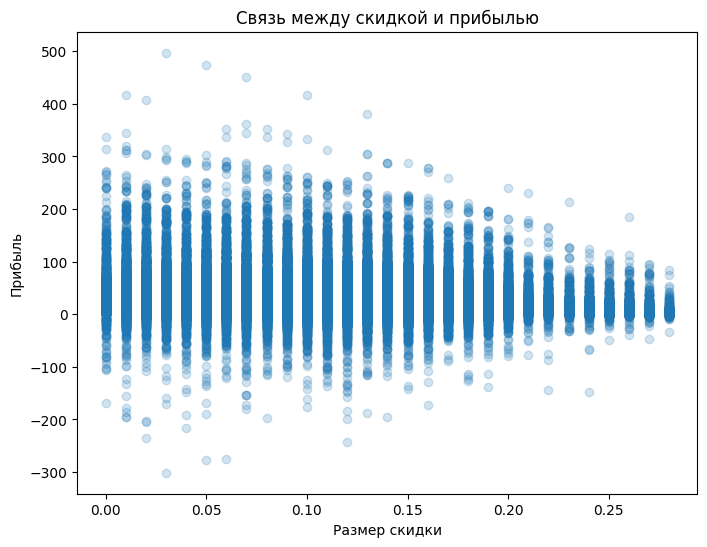

In [91]:
plt.figure(figsize=(8,6))

plt.scatter(
    full_sales['discount_pct'],
    full_sales['profit'],
    alpha=0.2
)

plt.xlabel("Размер скидки")
plt.ylabel("Прибыль")
plt.title("Связь между скидкой и прибылью")

plt.show()

Диаграмма рассеяния демонстрирует отрицательную зависимость между размером скидки и прибылью продажи. При увеличении скидки наблюдается снижение верхней границы возможной прибыли, а продажи с высокой прибылью встречаются значительно реже. При этом разброс значений прибыли остается достаточно большим, что свидетельствует о влиянии на прибыль и других факторов (категории товара, бренда, себестоимости, количества товара и др.).

Вывод по гипотезе

Корреляционный анализ Спирмена показал наличие статистически значимой отрицательной связи между размером скидки и прибылью продажи (ρ = -0.236, p < 0.001). Нулевая гипотеза была отвергнута. Несмотря на статистическую значимость результата, сила связи является слабой, что указывает на то, что размер скидки оказывает влияние на прибыль, однако не является единственным определяющим фактором ее формирования.

Бизнес-рекомендации

Полученные результаты свидетельствуют о необходимости осторожного применения скидочной политики. Увеличение размера скидки сопровождается снижением прибыли по отдельным продажам, поэтому предоставление высоких скидок должно иметь четкое бизнес-обоснование (стимулирование спроса, распродажа остатков, привлечение новых клиентов и т.п.). Для повышения эффективности рекомендуется анализировать оптимальный размер скидки отдельно по категориям товаров, брендам и сегментам клиентов, чтобы находить баланс между ростом объема продаж и сохранением прибыльности.

5.6. Гипотеза № 6. Связан ли способ оплаты с фактом возврата товара?

Формулировка гипотез
H₀

Способ оплаты и факт возврата независимы.

(Между ними нет статистической связи.)

H₁

Способ оплаты и факт возврата статистически связаны.

Так как оба признака (способ оплаты, факт возврата) являются категориальными, для проведения статистического теста выбран хи-квадрат Пирсона

In [96]:
#строим таблицу сопряженности
contingency = pd.crosstab(full_sales['payment_method'], full_sales['is_return'])
contingency

is_return,False,True
payment_method,,
Card,126198,3812
Cash,38799,1264
Online,29028,899


In [97]:
chi2, p_value, dof, expected = stats.chi2_contingency(contingency)

print(f"Chi-square = {chi2:.3f}")
print(f"p-value = {p_value:.5f}")
print(f"Степени свободы = {dof}")

Chi-square = 5.285
p-value = 0.07117
Степени свободы = 2


In [98]:
alpha = 0.05

if p_value < alpha:
    print("Отвергаем H₀.")
    print("Способ оплаты статистически связан с возвратом товара.")
else:
    print("Нет оснований отвергнуть H₀.")
    print("Статистически значимой связи не обнаружено.")

Нет оснований отвергнуть H₀.
Статистически значимой связи не обнаружено.


In [100]:
round(pd.crosstab(full_sales['payment_method'], full_sales['is_return'], normalize='index') * 100, 2)

is_return,False,True
payment_method,,
Card,97.07,2.93
Cash,96.84,3.16
Online,97.00,3.00


Вывод по гипотезе

Критерий χ² Пирсона не выявил статистически значимой связи между способом оплаты и фактом возврата товара (χ² = 5.285, p = 0.071). При уровне значимости 5% отсутствуют основания отвергнуть нулевую гипотезу. Таким образом, вероятность возврата товара статистически не зависит от выбранного способа оплаты.

Бизнес-рекомендации

Полученные результаты показывают, что изменение или стимулирование отдельных способов оплаты само по себе не приведет к снижению количества возвратов. Следовательно, мероприятия по уменьшению возвратов следует направить на другие факторы, такие как качество товаров, описание продукции, работа персонала, логистика и ожидания покупателей.

6. Итоговые выводы

В ходе исследования был проведен комплексный статистический анализ набора данных, содержащего 200 000 транзакций розничной торговли. Выполнена предварительная подготовка данных, исследовательский анализ (EDA), рассчитаны основные описательные статистики и проверены шесть статистических гипотез.

В результате исследования установлено следующее:

- Средняя прибыль статистически различается между категориями товаров. Наибольшую прибыль приносят категории Kitchen и Garden, тогда как категория Cleaning демонстрирует наименьшую прибыльность.
- Статистически значимых различий средней прибыли между покупателями мужского и женского пола не обнаружено.
- Прибыль существенно зависит от ценового сегмента товара. Наибольшую среднюю и суммарную прибыль обеспечивают товары сегмента Premium, что подтверждено тестом Welch ANOVA и последующим анализом Games-Howell.
- Средняя прибыль статистически различается между уровнями программы лояльности. Несмотря на более высокую среднюю прибыль одной покупки у клиентов Bronze и Silver, наибольший вклад в общую прибыль компании обеспечивают клиенты уровня Platinum благодаря значительно большему количеству совершаемых покупок.
- Между размером предоставляемой скидки и прибылью выявлена статистически значимая отрицательная корреляционная связь. С увеличением размера скидки прибыль одной продажи имеет тенденцию к снижению.
- Статистически значимой зависимости между способом оплаты и вероятностью возврата товара обнаружено не было.

Проведенный анализ позволил выявить основные факторы, оказывающие влияние на прибыль компании, и подтвердил возможность применения статистических методов для поддержки принятия управленческих решений.

7. Бизнес-рекомендации

По результатам исследования могут быть предложены следующие рекомендации:

- Увеличить долю продаж товаров сегмента Premium, поскольку именно они обеспечивают максимальную среднюю и суммарную прибыль компании.
- Пересмотреть ассортимент категорий с низкой прибыльностью (например, Cleaning), проанализировав возможность повышения маржинальности либо оптимизации закупочной политики.
- При формировании маркетинговых кампаний учитывать, что увеличение скидки сопровождается снижением прибыли одной продажи. Размер скидок рекомендуется рассчитывать исходя из ожидаемого роста объема продаж и итоговой прибыльности, а не использовать максимальные скидки без экономического обоснования.
- Продолжить развитие программы лояльности, уделяя особое внимание удержанию клиентов уровня Platinum, поскольку именно они формируют наибольшую долю общей прибыли компании.
- Не разделять маркетинговые стратегии по полу покупателей, поскольку статистически значимых различий в уровне прибыли между мужчинами и женщинами выявлено не было.
- Не рассматривать изменение способов оплаты как инструмент снижения количества возвратов, так как статистически значимой связи между способом оплаты и возвратом товара обнаружено не было.

8. Ограничения исследования

При интерпретации результатов исследования необходимо учитывать следующие ограничения:

- Анализ выполнен на синтетическом учебном наборе данных, который моделирует работу розничной сети и может не отражать все особенности реального бизнеса.
- В исследовании рассматривались только представленные в наборе данных признаки. Потенциальное влияние сезонности, маркетинговых кампаний, конкурентной среды, региональных особенностей и других внешних факторов не анализировалось.
- Корреляционный анализ позволяет выявить наличие статистической связи между признаками, однако не подтверждает причинно-следственные зависимости.
- Полученные выводы справедливы для исследуемого набора данных и требуют дополнительной проверки при использовании на реальных коммерческих данных.